## Fine-Tuning Llama 3.2 1B — Compare Vehicles Specs Tool

## Definizione del problema nella pipeline agentica

Il componente sviluppato è uno strumento di confronto tecnico tra veicoli: dato il profilo di due veicoli (auto o moto), produce un'analisi comparativa strutturata che decreta un vincitore per quattro categorie (Prestazioni, Consumi, Sicurezza, Comfort) e un verdetto finale.

- Input: due schede tecniche di veicoli, fornite in tag XML, più un system prompt che definisce il ruolo del modello e il formato dell'output.
- Output: un confronto in Markdown strutturato, con vincitore e motivazione per ogni categoria e un verdetto finale.
- Ruolo nella pipeline: questo componente è pensato come il "tool di comparazione" che un agente può invocare quando l'utente chiede di confrontare due modelli. L'output strutturato e ripetibile è ciò che lo rende utilizzabile: la struttura infatti è un requisito funzionale, e non estetico, affinché la comparazione tra due veicoli risulti estremamente discorsiva, dettagliatta ma allo stesso tempo sintetica, per essere utilizzato nella pipeline principale di stesura dell'articolo come fonte.

In [ ]:
!pip install -q -U \
    "transformers>=4.45.0" \
    "peft>=0.13.0" \
    "bitsandbytes>=0.43.0" \
    "datasets>=3.0.0" \
    "trl>=0.12.0" \
    "accelerate>=1.0.0" 2>/dev/null

!pip install --upgrade "torchao>0.16.0" 2>/dev/null

In [ ]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True" 

MODEL_ID     = "meta-llama/Llama-3.2-1B-Instruct"
DATASET_PATH = "/kaggle/working/automotive_dataset_final.jsonl"
OUTPUT_DIR   = "/kaggle/working/llama32_automotive"
MERGED_DIR   = "/kaggle/working/llama32_automotive_merged"

N_EPOCHS = 5
LR       = 2e-4
LORA_R   = 16

In [ ]:
import torch
import json
import gc, math
import re
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from sklearn.metrics import classification_report, accuracy_score

### Login HuggingFace

Richiede un secret `HF_TOKEN` in Kaggle con accesso alla licenza di `meta-llama/Llama-3.2-1B-Instruct`.

In [ ]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
login(token=secrets.get_secret("HF_TOKEN"))

# Dataset

## Definizione del dataset

Il dataset è stato generato da noi, ed è una scelta motivata. Cercando su Hugging Face e Kaggle non abbiamo trovato un dataset adatto al compito: quelli disponibili coprivano una sola dimensione per volta, alcuni solo i dati di motore e prestazioni, altri solo gli optional e i costi, altri solo i consumi, e nessuno conteneva, in un unico formato coerente, tutti i dati tecnici necessari per un confronto completo su tutte e quattro le categorie. Unire più dataset eterogenei avrebbe comportato problemi non banali di allineamento dei formati, delle unità di misura e della copertura dei campi. Generare i dati ci ha permesso di avere esempi completi, coerenti e nel formato esatto richiesto, e di controllarne il bilanciamento (auto/moto, vittorie nette/pareggi).

Formato degli esempi. Ogni esempio è una conversazione in formato chat con tre messaggi: `system` (ruolo e formato di output), `user` (le schede tecniche dei due veicoli), `assistant` (il confronto strutturato di riferimento). È il formato atteso dai modelli "Instruct" come Llama 3.2, e quello che `SFTTrainer` usa per applicare il chat template e calcolare la loss sui soli token della risposta.

Perché JSONL. Abbiamo salvato il dataset in JSONL (un oggetto JSON per riga) per tre motivi: è il formato standard atteso da `load_dataset` della libreria `datasets`; permette di leggere e validare il file riga per riga senza caricarlo tutto in memoria; ed è facile da estendere accodando nuove righe, come abbiamo fatto unendo i file originali con quelli generati per espandere il dataset.

In [ ]:
# Merge dei dataset generati

import json

files = [
    "/kaggle/input/datasets/gioconta/dataset-fine-tuning/dataset_01.jsonl",          
    "/kaggle/input/datasets/gioconta/dataset-fine-tuning/dataset_02.jsonl",
    "/kaggle/input/datasets/gioconta/dataset-fine-tuning/dataset_03.jsonl",
    "/kaggle/input/datasets/gioconta/dataset-fine-tuning/dataset_04.jsonl",
    "/kaggle/input/datasets/gioconta/dataset-fine-tuning/dataset_05.jsonl",
    "/kaggle/input/datasets/gioconta/dataset-fine-tuning/dataset_06.jsonl",
    "/kaggle/input/datasets/gioconta/dataset-fine-tuning/dataset_07.jsonl",
    "/kaggle/input/datasets/gioconta/dataset-fine-tuning/dataset_new.jsonl",
]

all_examples = []
for f in files:
    with open(f, "r", encoding="utf-8") as fp:
        for line in fp:
            if line.strip():
                all_examples.append(json.loads(line.strip()))

with open("automotive_dataset_final.jsonl", "w", encoding="utf-8") as fp:
    for ex in all_examples:
        fp.write(json.dumps(ex, ensure_ascii=False) + "\n")

print(f"Dataset finale: {len(all_examples)} esempi")

Dataset finale: 274 esempi


In [ ]:
dataset_full = load_dataset("json", data_files=DATASET_PATH, split="train")

# Split a 3 vie con dimensioni esatte: 174 train / 60 validation / 40 test
# Prima separiamo i 40 del test, poi i 60 della validation dal resto.
temp = dataset_full.train_test_split(test_size=40, seed=42)
test_dataset_raw = temp["test"]          # 40 esempi per il test finale
train_val = temp["train"]                # 234 esempi rimanenti

temp2 = train_val.train_test_split(test_size=60, seed=42)
train_dataset = temp2["train"]           # 174 esempi per il training
eval_dataset  = temp2["test"]            # 60 esempi per la validation

print(f"Totale     : {len(dataset_full)}")
print(f"Train      : {len(train_dataset)}")
print(f"Validation : {len(eval_dataset)}")
print(f"Test       : {len(test_dataset_raw)}")

Generating train split: 0 examples [00:00, ? examples/s]

Totale     : 274
Train      : 174
Validation : 60
Test       : 40


# Tokenizer e Quantizzazione per QLoRA

Questa cella introduce la tecnica QLoRA (Quantized LoRA). Lo scopo è quello di comprimere il modello affinché durante l'addestramento occupi una porzione di VRAM inferiore all'addestramento originale con LoRA.


Tokenizer invece, serve per configurare lo strumento che traduce gli input umani in token, e come impacchettare questi numeri.

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, #Qui converto i pesi del modello a 4 bit (invece dei 16bit standard)
    bnb_4bit_use_double_quant=True, #Uso una doppia quantizzazione, cioè quantizzo anche le costanti di quantizzazione
    #definisco la struttura dei 4bit da usare, in formato standard normal float
    #ottimizzato per i pesi delle reti neurali che hanno una distribuzione normale
    bnb_4bit_quant_type="nf4", 
    #questo parametro mi permette di eseguire una dequantizzazione temporanea
    #sebbene i pesi sono quantizzati a 4bit, durante l'addestramento
    #vengono momentaneamente decompressi a 16bit, per poi tornare a 4
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
#Prendo il dizionario di parole del modello base
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
#Siccome è richiesto che  tutte le frasi (in batch) durante l'addestramento
#abbiano la stessa lunghezza, devo cercare di riempire tramite il padding
#E siccome alcuni modelli non hanno un token di padding (come LLama) riciclo
#il token di End of Sequence alla fine, e lo metto a destra (quindi alla fine della frase)
#fino a raggiungere le dimensioni prefissate di 2048
if tokenizer.pad_token is None: 
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "right"
tokenizer.model_max_length = 2048

print(f"Vocabolario : {tokenizer.vocab_size:,}")
print(f"Pad token   : '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Vocabolario : 128,000
Pad token   : '<|eot_id|>' (id=128009)


In [ ]:
#Scelgo il modello per la generazione di testo
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    #uso la configurazione di quantizzazione sopra
    quantization_config=bnb_config,
    #spalmo l'intero modello in tutta la VRAM in modo automatico
    device_map="auto",
    #forzo il modello ad usare il formato bfloat16, coerentemente con la de-quantizzazione
    dtype=torch.bfloat16,
    #Uso come attention lo scaled dot product attention
    attn_implementation="sdpa"
)
#Non mi interessa usare la KV cache (cache per Key-Value) che incrementa le prestazioni nella genrazione del testo
model.config.use_cache = False
#preparo il modello all'addestramento abilitando il gradiend checkpointing
#una tecnica che permette di risparmiare capacità per tempo di computazione
model = prepare_model_for_kbit_training(model)

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

# LoRA

### Ricerca degli iperparametri

Testiamo 4 configurazioni variando rango LoRA, learning rate e numero di epoche.
L'obiettivo è capire la configurazione di addestramento migliore, basandoci non sulla training loss, ma sulla validation loss, evitando che il modello vada in overfitting.

Configurazioni:
- A (attuale): r=16, lr=2e-4, epochs=5
- B (rango ridotto): r=8, lr=2e-4, epochs=5
- C (learning rate piu' alto): r=16, lr=5e-4, epochs=5
- D (numero di epoche aumentato): r=16, lr=5e-4, epochs=7


In [ ]:
configs = {
    "A: r=16, lr=2e-4, ep=5": {"r": 16, "lr": 2e-4, "epochs": 5},
    "B: r=8,  lr=2e-4, ep=5": {"r": 8,  "lr": 2e-4, "epochs": 5},
    "C: r=16, lr=5e-4, ep=5": {"r": 16, "lr": 5e-4, "epochs": 5},
    "D: r=16, lr=5e-4, ep=7": {"r": 16, "lr": 5e-4, "epochs": 7},
}
hp_results = {}

del model
gc.collect()
torch.cuda.empty_cache()

#Per la ricerca usiamo un sottoinsieme: serve a confrontare le config,
#non a produrre il modello finale (che alleniamo dopo sui dati completi).
#serve a velocizzare il processo di ricerca dei parametri
train_search = train_dataset.select(range(min(120, len(train_dataset))))

for name, cfg in configs.items():
    print(f"\n{'='*60}")
    print(f"  TRAINING CONFIG: {name}")
    print(f"{'='*60}")
    # Carica modello fresco per ogni config 
    model_hp = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, #modello base
        quantization_config=bnb_config, #configurazione di quantizzazione sopra
        device_map="auto", #mappo automaticamente tutto il modello in VRAM
        dtype=torch.bfloat16, #uso il formato a 16bit coerentemente per la dequantizzazione
        attn_implementation="sdpa" #uso come algoritmo di attention lo Scaled Dot Product
    )
    #non mi serve la cache KV per produrre risposte più veloci
    model_hp.config.use_cache = False
    #preparo il modello all'addestramento impostando il gradiend checkpointing per la backpropagation
    model_hp = prepare_model_for_kbit_training(model_hp)
    lora_cfg = LoraConfig(
        r=cfg["r"], #LR della config attuale
        lora_alpha=cfg["r"] * 2, #alpha per regolare l'aumento della matrice dei pesi nuova
        lora_dropout=0.05, #congelo il 5% delle connessioni LoRA per evitare l'overfitting
        bias="none", #uso il bias di base del modello
        task_type="CAUSAL_LM", #lo configuro come modello per la generazione di testo
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", #agisco sui valori di Key,Value,Query,Output della self attention
                        "gate_proj", "up_proj", "down_proj"] #e sui valori delle reti feed foward
    )
    model_hp = get_peft_model(model_hp, lora_cfg)
    model_hp.print_trainable_parameters()
    args_hp = SFTConfig(
        output_dir=f"{OUTPUT_DIR}_hp_{name[0]}",
        num_train_epochs=cfg["epochs"], #uso il numero di epoche della config attuale
        per_device_train_batch_size=2, #processo 2 esempi alla volta durante il trainig
        gradient_accumulation_steps=8, #aggiorno i pesi dopo 8 batch (quindi arrivati a 16 esempi totali)
        per_device_eval_batch_size=1, #stessa cosa di sopra ma per l'eval set
        eval_accumulation_steps=1, #sposto i risultati del modello nella RAm invece che tenerli in VRAM
        learning_rate=cfg["lr"], #uso il lr della config attuale
        lr_scheduler_type="cosine", #la lr non è fissa, ma segue una curva a coseno, prima alta e poi cresce lentamente
        warmup_ratio=0.05, #per il primo 5% di addestramento la lr parte da 0 e poi sale, per prevenire sbilanciamenti nell'addestramento
        optim="paged_adamw_8bit", #algoritmo di aggiornamento dei pesi che riduce l'impatto nella GPU e che scarica nella RAM se la VRAM è piena
        fp16=False, #uso un formato float nuovo invece che il vecchio
        bf16=True,
        gradient_checkpointing=True, #invece che salvare tutti i controlli per la backpropagation, salvo solo i punti di riferimento
        eval_strategy="epoch",
        logging_strategy="steps", #ogni 5 passi vediamo i log di addestramento
        logging_steps=5,
        save_strategy="no",       # non salvo i dati di addestramento perché qui non mi interessano
        report_to="none", #non mi interessa monitorare con piattaforme esterne
        dataset_text_field=None #la formattazione dei token è già gestita da Tokenizer, quindi SFTTrainer la prende da la
    )
    trainer_hp = SFTTrainer(
        model=model_hp, #modello vuoto
        train_dataset=train_search, #dataset di train ridotto
        eval_dataset=eval_dataset, #dataset di evaluation
        processing_class=tokenizer, #dizionario tokenizer dii sopra
        args=args_hp #i parametri della SFTConfig
    )
    trainer_hp.train()
    eval_result = trainer_hp.evaluate()
    val_loss = eval_result["eval_loss"]
    val_ppl = math.exp(val_loss)
    # Salva la storia della training loss per confronto
    train_losses = [h["loss"] for h in trainer_hp.state.log_history if "loss" in h]
    final_train_loss = train_losses[-1] if train_losses else float("inf")
    hp_results[name] = {
        "val_loss": val_loss,
        "val_ppl": val_ppl, 
        "train_loss_finale": final_train_loss,
        "parametri_allenabili": sum(p.numel() for p in model_hp.parameters() if p.requires_grad),
    }
    print(f"  -> val_loss={val_loss:.4f}, val_ppl={val_ppl:.2f}, train_loss={final_train_loss:.4f}")
    # Pulizia memoria prima della prossima config 
    del trainer_hp
    del model_hp
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# Tabella di confronto finale 
print("\n" + "=" * 75)
print("  CONFRONTO IPERPARAMETRI — ordinato per validation loss (crescente)")
print("=" * 75)
print(f"  {'Config':<28} {'Param. allenati':>15} {'Train loss':>12} {'Val loss':>10} {'Val PPL':>10}")
print("-" * 75)
for name, res in sorted(hp_results.items(), key=lambda x: x[1]["val_loss"]):
    print(f"  {name:<28} {res['parametri_allenabili']:>15,} {res['train_loss_finale']:>12.4f} {res['val_loss']:>10.4f} {res['val_ppl']:>10.2f}")
best_name = min(hp_results, key=lambda x: hp_results[x]["val_loss"])
best_cfg = configs[best_name]
print(f"\n  MIGLIOR CONFIG: {best_name}")
print(f"  -> Usa r={best_cfg['r']}, lr={best_cfg['lr']}, epochs={best_cfg['epochs']} per il training finale.")


  TRAINING CONFIG: A: r=16, lr=2e-4, ep=5


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


/tmp/ipykernel_58/3055600748.py:45: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  args_hp = SFTConfig(


...

trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


/tmp/ipykernel_58/3055600748.py:45: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  args_hp = SFTConfig(
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,2.060348,1.004563,1.027916,0.803915,74860.000000
2,0.834659,0.847405,0.883921,0.823256,149720.000000
3,0.756710,0.786266,0.777683,0.835419,224580.000000
4,0.583934,0.775118,0.654270,0.838608,299440.000000
5,0.478062,0.769640,0.653616,0.841168,374300.000000
6,0.446795,0.781294,0.617097,0.840812,449160.000000
7,0.399112,0.782585,0.613087,0.841109,524020.000000


Training Loss,Validation Loss,Epoch,Entropy,Mean Token Accuracy,Num Tokens
0.399112,0.782585,7,0.613087,0.841109,524020.000000


  -> val_loss=0.7826, val_ppl=2.19, train_loss=0.3991

  CONFRONTO IPERPARAMETRI — ordinato per validation loss (crescente)
  Config                       Param. allenati   Train loss   Val loss    Val PPL
---------------------------------------------------------------------------
  C: r=16, lr=5e-4, ep=5            11,272,192       0.5576     0.7769       2.17
  D: r=16, lr=5e-4, ep=7            11,272,192       0.3991     0.7826       2.19
  A: r=16, lr=2e-4, ep=5            11,272,192       0.7723     0.8642       2.37
  B: r=8,  lr=2e-4, ep=5             5,636,096       0.8777     0.9326       2.54

  MIGLIOR CONFIG: C: r=16, lr=5e-4, ep=5
  -> Usa r=16, lr=0.0005, epochs=5 per il training finale.


### Commento sulla ricerca degli iperparametri

Dalla tabella emerge quale configurazione ha il maggiore impatto sulla validation loss.
Proseguiamo con la configurazione migliore per il training finale.

> Ogni config e' stata addestrata da zero su un modello caricato
> fresco, per evitare che i risultati di una run influenzino la successiva.
> I risultati sono confrontati sulla validation loss.

In [ ]:
N_EPOCHS = 5
LR       = 5e-4
LORA_R   = 16

### Training

In [ ]:
#Parametri analoghi a sopra
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, #Prendo il modello base per la generazione di testo
    quantization_config=bnb_config, #applico la configurazione LoRA
    device_map="auto", #mappo tutto il modello nella VRAM autoamticamente
    dtype=torch.bfloat16, #uso il formato a 16bit coerentemente con la de-quantizzazione dei pesi
    attn_implementation="sdpa" #e uso come algoritmo di attention lo scaled dot product
)
model.config.use_cache = False #non mi interessa la KV cache
model = prepare_model_for_kbit_training(model) #preparo il modello per l'addestramento

lora_config = LoraConfig(
    r=LORA_R, #Uso il LR della config C, quindi 5e-4
    lora_alpha=LORA_R * 2, #l'alpha indica il tasso di aggiornamento dei valori della nuova matrice dei pesi
    lora_dropout=0.05, #prevendo l'overfitting spegnendo il 5% delle connesioni LoRA ad ogni iterazione
    bias="none", #uso il bias originale del modello
    task_type="CAUSAL_LM", #lo addestro per generare output testuali
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", #aggiorno gli strati di Key,Query,Value e Output della self attention
                    "gate_proj", "up_proj", "down_proj"] #e i livelli lineari delle reti feed foward
)
model = get_peft_model(model, lora_config) #applico la configurazione LoRA per il parameter efficient fine tuning
model.print_trainable_parameters() #e guardo i parametri addestrabili

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039


In [ ]:
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=N_EPOCHS, #5 epoche totali
    per_device_train_batch_size=2, #2 esempi alla volta durante il training
    gradient_accumulation_steps=8, #aggiorno i pesi dopo 8 step totali (quindi dopo 16 esempi)
    learning_rate=LR, #uso la LR di 5e-4
    lr_scheduler_type="cosine", #la lr decresce a coseno
    warmup_ratio=0.05, #per il 5% del training la lr parte da zero e sale lentamente per evitare sbilanciamenti nel training
    optim="paged_adamw_8bit", #uso l'algoritmo di ottimizzazione AdamW
    fp16=False, #forzo il formaato a 16bit float nuovo
    bf16=True,
    gradient_checkpointing=True, #il gradiend checkpoiting per la backpropagation
    eval_strategy="epoch", #esegue il test sull'evaluation alla fine di ogni epoca
    logging_strategy="steps", #stampo le statistiche di avanzamento a ogni step (e in particolare ad ogni 5)
    logging_steps=5,        
    save_strategy="epoch", #salvo un checkpoint alla fine di ogni epoca
    per_device_eval_batch_size=1,      #scarico in memoria 1 test di eval alla volta
    eval_accumulation_steps=1, #idem qui
    save_total_limit=2, #fino ad un massimo di 2 salvataggi per epoca
    report_to="none", #non uso monitoraggi esterni
    dataset_text_field=None  #dico al SFTTrainer di usare la config tokenizer che ho scritto sopra
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/tmp/ipykernel_58/2379574702.py:1: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(


In [ ]:
#Eseguo una pulizia della memoria, e anche della VRAM ma aspetto che la GPU abbia finito di fare i calcoli per pulire
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [ ]:
#Applico la config di training impostata sopra
trainer = SFTTrainer(
    model=model, #modello base
    train_dataset=train_dataset, #dataset di training con 174 esempi
    eval_dataset=eval_dataset, #dataset di eval con 60 esempi
    processing_class=tokenizer, #imposto il tokenizer
    args=training_args #imposto i parametri sopra
)

import math
baseline_eval = trainer.evaluate() #misuro l'eval all'inizio del training, cioè cerco di capire quanto il modello
#sia perplesso dagli elementi del dataset di eval che ha ricevuto (non avendoli mai visti sarà alta)
print("\n\n")
baseline_ppl = math.exp(baseline_eval["eval_loss"])
print(f"Baseline perplexity (prima del training): {baseline_ppl:.2f}")
print("\n\n")
train_result = trainer.train()
print(f"Loss finale: {train_result.training_loss:.4f}") #misuro la loss alla fine del training
print("\n\n")
finetuned_eval = trainer.evaluate() #rimisuro la perplexity dopo e sicuramente sarà bassa
finetuned_ppl = math.exp(finetuned_eval["eval_loss"])
print("\n\n")
print(f"Fine-tuned perplexity (dopo il training): {finetuned_ppl:.2f}")
print(f"Delta PPL: {finetuned_ppl - baseline_ppl:+.2f}") #calcolo di quanto è migliorata la perplexity in totale
print("\n\n")

trainer.save_model(OUTPUT_DIR) #salvo i pesi LoRA così posso fare il merge anche in locale
tokenizer.save_pretrained(OUTPUT_DIR) #salvo le regole di tokenizzazione e il dizionario

Tokenizing train dataset:   0%|          | 0/174 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,Entropy,Mean Token Accuracy,Num Tokens
No log,2.404320,0,1.795810,0.573195,0.000000


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.





Baseline perplexity (prima del training): 11.07





Epoch,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
1,1.108655,0.916614,0.958744,0.814473,108259.000000
2,0.728272,0.793172,0.763674,0.833785,216518.000000
3,0.588015,0.748366,0.713771,0.842030,324777.000000
4,0.509334,0.738628,0.651863,0.844933,433036.000000
5,0.479762,0.734953,0.652014,0.845679,541295.000000


Loss finale: 0.7720





Training Loss,Validation Loss,Epoch,Entropy,Mean Token Accuracy,Num Tokens
0.479762,0.734953,5,0.652014,0.845679,541295.000000





Fine-tuned perplexity (dopo il training): 2.09
Delta PPL: -8.99





('/kaggle/working/llama32_automotive/tokenizer_config.json',
 '/kaggle/working/llama32_automotive/chat_template.jinja',
 '/kaggle/working/llama32_automotive/tokenizer.json')

### Curva di Loss del Training

La loss di training mostra se il modello sta imparando. Una curva che scende e poi si appiattisce indica convergenza; una loss che risale segnalerebbe overfitting.

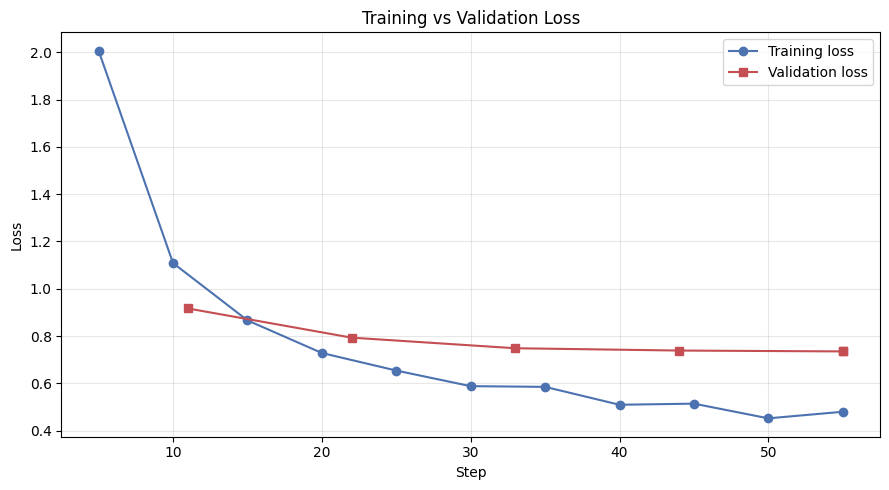

Training loss iniziale: 2.0068
Training loss finale:   0.4798
Validation loss finale: 0.7350


In [ ]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
steps  = [h["step"] for h in history if "loss" in h]
losses = [h["loss"] for h in history if "loss" in h]
eval_epochs = [h["epoch"] for h in history if "eval_loss" in h]
eval_losses = [h["eval_loss"] for h in history if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps, losses, marker="o", label="Training loss", color="#4C72B0")
# Mappa le epoche sugli step corrispondenti per sovrapporre la eval loss
steps_per_epoch = max(steps) / N_EPOCHS
eval_steps = [int(e * steps_per_epoch) for e in eval_epochs]
ax.plot(eval_steps, eval_losses, marker="s", label="Validation loss", color="#C44E52")
ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"Training loss iniziale: {losses[0]:.4f}" if losses else "Nessun log")
print(f"Training loss finale:   {losses[-1]:.4f}" if losses else "")
if eval_losses:
    print(f"Validation loss finale: {eval_losses[-1]:.4f}")

### Efficienza di LoRA: Parametri Allenabili

LoRA addestra solo una piccola frazione dei parametri totali. Questo grafico quantifica il risparmio rispetto al full fine-tuning, in cui si aggiornerebbe il 100% dei pesi. Il modello ha 1.23 miliardi di pesi reali. Il totale qui risulta 760M per via della quantizzazione a 4-bit: PyTorch conta  i blocchi di memoria allocati, e la compressione impacchetta i pesi a due a due, dimezzandone virtualmente il numero letto da p.numel(). I parametri LoRA (addestrabili) rimangono invece in formato standard e vengono 
contati per intero (~11.2M). 
Questo grafico mostra quindi l'occupazione fisica in VRAM, non la matematica.

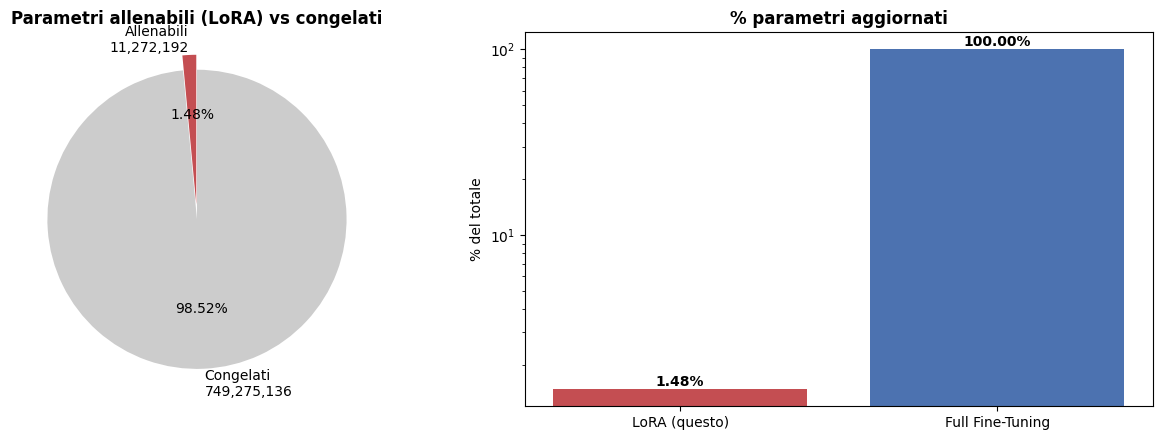

Parametri totali     : 760,547,328
Parametri allenabili : 11,272,192 (1.48%)


In [ ]:
import matplotlib.pyplot as plt

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
frozen    = total - trainable

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Torta: allenabili vs congelati
axes[0].pie([trainable, frozen],
            labels=[f"Allenabili\n{trainable:,}", f"Congelati\n{frozen:,}"],
            colors=["#C44E52", "#CCCCCC"], autopct="%1.2f%%", startangle=90,
            explode=(0.1, 0))
axes[0].set_title("Parametri allenabili (LoRA) vs congelati", fontweight="bold")

# Confronto LoRA vs full fine-tuning ipotetico
methods = ["LoRA (questo)", "Full Fine-Tuning"]
percents = [100 * trainable / total, 100.0]
bars = axes[1].bar(methods, percents, color=["#C44E52", "#4C72B0"])
axes[1].set_title("% parametri aggiornati", fontweight="bold")
axes[1].set_ylabel("% del totale")
axes[1].set_yscale("log")
for bar, pct in zip(bars, percents):
    axes[1].text(bar.get_x() + bar.get_width()/2, pct, f"{pct:.2f}%",
                 ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Parametri totali     : {total:,}")
print(f"Parametri allenabili : {trainable:,} ({100*trainable/total:.2f}%)")

### Backup degli adattatori LoRA in formato ZIP

In [ ]:
import shutil, os

zip_path = "/kaggle/working/llama32_automotive_adapter"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
print(f"{zip_path}.zip — {os.path.getsize(zip_path + '.zip') / 1e6:.1f} MB")

# Fase di inferenza che testa il modello Base con quello Fine Tuned

## Definizione della baseline

Come baseline usiamo lo stesso modello Llama 3.2 1B senza fine-tuning (con l'adapter LoRA disattivato), a cui forniamo lo stesso system prompt che descrive il formato richiesto.

La scelta è deliberata: confrontare il fine-tuned con il modello base già guidato dal prompt rende il confronto onesto. Misuriamo così il valore aggiunto del fine-tuning a parità di istruzioni: quanto migliora il modello quando, oltre a dirgli il formato nel prompt, glielo insegniamo con l'addestramento.

Tecnicamente, otteniamo le due condizioni sullo stesso modello caricato in memoria, attivando e disattivando l'adapter, così il confronto è perfettamente allineato e non dipende da differenze di caricamento.

In [ ]:
SYSTEM_PROMPT = (
    "Sei un ingegnere specializzato in comparazioni automobilistiche e motociclistiche. "
    "Il tuo compito e analizzare i profili tecnici di due veicoli e decretare un vincitore "
    "per categorie specifiche, basandoti ESCLUSIVAMENTE sui dati forniti nei tag XML.\n\n"
    "STRUTTURA DI OUTPUT OBBLIGATORIA:\n"
    "Rispondi usando esattamente questo formato in Markdown.\n\n"
    "### Analisi Comparativa: [Nome Veicolo 1] vs [Nome Veicolo 2]\n\n"
    "**1. Prestazioni e Motore**\n"
    "*Vincitore:* [Nome Veicolo o Pareggio]\n"
    "*Motivazione:* [Spiegazione tecnica in 1-2 frasi basata sui dati]\n\n"
    "**2. Consumi e Costi Operativi**\n"
    "*Vincitore:* [Nome Veicolo o Pareggio]\n"
    "*Motivazione:* [Spiegazione tecnica in 1-2 frasi basata sui dati]\n\n"
    "**3. Sicurezza e Affidabilità**\n"
    "*Vincitore:* [Nome Veicolo o Pareggio]\n"
    "*Motivazione:* [Spiegazione tecnica in 1-2 frasi basata sui difetti o test NCAP]\n\n"
    "**4. Comfort e Tecnologia**\n"
    "*Vincitore:* [Nome Veicolo o Pareggio]\n"
    "*Motivazione:* [Spiegazione tecnica in 1-2 frasi basata sulle dotazioni]\n\n"
    "**Verdetto Finale**\n"
    "[Un paragrafo conclusivo di 3 righe che riassume a chi è destinato il primo veicolo e a chi il secondo].\n\n"
    "NON OMETTERE NESSUN CAMPO DELLA STRUTTURA DI OUTPUT, INCLUDI SEMPRE TUTTE LE CATEGORIE E IL VERDETTO FINALE.\n"
    "IL VERDETTO FINALE VA INCLUSO IN OGNI CASO.\n"
)

# Prompt di test con veicoli NON presenti nel dataset di training
TEST_PROMPT = """<veicolo_1>
Marca: Volkswagen
Modello: Golf 1.5 eTSI
Dati estratti: Motore 1.5 TSI mild-hybrid da 150 CV. Consumo WLTP 5.9 l/100km. Prezzo base 29.900 EUR. Euro NCAP 5 stelle (2020), Travel Assist di serie dal livello Life. Infotainment MIB3 da 8.25 pollici, Digital Cockpit da 10 pollici, clima bi-zona.
</veicolo_1>

<veicolo_2>
Marca: Mazda
Modello: 3 Skyactiv-G 2.0
Dati estratti: Motore 2.0 benzina da 150 CV. Consumo WLTP 6.4 l/100km. Prezzo base 28.500 EUR. Euro NCAP 5 stelle (2019), i-Activsense parzialmente di serie. Infotainment Mazda Connect da 8.8 pollici con controllo rotativo, Head-Up Display disponibile.
</veicolo_2>

Genera la comparazione seguendo le istruzioni del sistema."""

In [ ]:
#Definisco la funzione che genera la risposta, passo il modello, il tokenizer, istruzioni di sistema
#la domanda, il numero massimo di token della risposta, e imposto la creativià del modello a falso (risposte sempre uguali)
def generate(model, tokenizer, system, user, max_new_tokens=1500, deterministic=False):
    #Riprendo la struttura del dataset, in cui c'è il Role Prompting (nel system) e la domanda che faccio
    messages = [
        {"role": "system",    "content": system},
        {"role": "user",      "content": user}
    ]
    #aggiungo una serie di tag nascosti che vede solo il modello e che lo aiutano a capire dove finisce
    #la mia domanda e dove deve iniziare a rispondere
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    #spedisce la domanda da numeri al formato PyTorch direttamente nella VRAM per essere calcolata
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    #Voglio una risposta non il training
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=1.0 if deterministic else 0.7, #imposto la creatività del modello: 1.0 per risposte deterministiche
            #0.7 per risposte più naturali
            do_sample=not deterministic, #il modello pesca la parola successiva valutando le opzioni possibili
            pad_token_id=tokenizer.eos_token_id #uso il token di EOS come padding (come sopra)
        )
    new_tokens = out[0][inputs.input_ids.shape[1]:]
    #traduco i numeri in parole, cancello i tag di sistema, e taglio gli spazi vuoti
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

In [ ]:
#carico il dizionario originale del modello
tokenizer_eval = AutoTokenizer.from_pretrained(MODEL_ID) 

#configuro il modello come sopra
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa"
)
base_model.config.use_cache = True
base_model.eval()

risposta_base = generate(base_model, tokenizer_eval, SYSTEM_PROMPT, TEST_PROMPT)
print("Modello Base: \n")
print(risposta_base)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Modello Base: 

**Analisi Comparativa: Volkswagen Golf 1.5 eTSI vs Mazda 3 Skyactiv-G 2.0**

**1. Prestazioni e Motore**
* **Vincitore:** Volkswagen Golf 1.5 eTSI
 + Motivazione: La prestazione del Volkswagen Golf 1.5 eTSI è superiore rispetto alla del Mazda 3 Skyactiv-G 2.0 grazie al motore più potente, che genera 150 CV di potenza a 4.500 giri/h.
 + Spiegazione tecnica: Il motore eTSI è un motore in linea a 6 cilindri, con una buona combinazione di potenza e velocità di scatto. La Volkswagen ha utilizzato la tecnologia Turbo, che aumenta la potenza fino a 150 CV. La Mazda, invece, ha utilizzato il motore benzina, che offre una prestazione più veloce ma meno potente rispetto alla versione eTSI.

**2. Consumi e Costi Operativi**
* **Vincitore:** Volkswagen Golf 1.5 eTSI
 + Motivazione: Il consumo di carburante dell'auto Volkswagen è inferiore rispetto al Mazda 3 Skyactiv-G 2.0 grazie alla tecnologia eTSI, che migliora l'efficienza e l'efficienza.
 + Spiegazione tecnica: Il Volkswagen h

In [ ]:
#prendo il modello e gli aggangio gli adattatori LoRA
ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
#qui uso la KV cache che mi serve per generare del testo più velocemente
ft_model.config.use_cache = True
#solo valutazione, niente addestramento
ft_model.eval()

#genero la risposta come sopra
risposta_ft = generate(ft_model, tokenizer_eval, SYSTEM_PROMPT, TEST_PROMPT, max_new_tokens=1500)
print("Modello fine-tuned: \n")
print(risposta_ft)

Modello fine-tuned: 

### Analisi Comparativa: Volkswagen Golf 1.5 eTSI vs Mazda 3 Skyactiv-G 2.0

1. Prestazioni e Motore
Vincitore: Pareggio
Motivazione: Entrambi i modelli dispongono di 150 CV, bilanciati perfettamente per la guida urbana.

2. Consumi e Costi Operativi
Vincitore: Pareggio
Motivazione: Le due vetture hanno consumi leggermente differenti, ma entrambe ottengono prestazioni migliori per l'uso quotidiano.

3. Sicurezza e Affidabilità
Vincitore: Pareggio
Motivazione: Entrambi i modelli dispongono di 5 stelle Euro NCAP e di sistemi di assistenza alla guida avanzati, sebbene la Mazda abbia un sistema di sicurezza leggermente più reattivo.

4. Comfort e Tecnologia
Vincitore: Pareggio
Motivazione: Le dotazioni tecnologiche sono simili, con l'infotainment da 8 pollici più grande della Mazda rispetto al 8.8 pollici della Mazda, ma entrambe offrono una qualità di interazione eccellente.

Verdetto Finale
Volkswagen Golf 1.5 eTSI e Mazda 3 Skyactiv-G 2.0 si bilanciano perfettament

### Installazione librerie di valutazione 


In [ ]:
!pip install -q evaluate bert_score rouge_score sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.6 MB/s eta 0:00:00


### Test Set

In [ ]:
# Costruisce il test set dal dataset split 
# Ogni esempio ha: input (messaggio user), reference (risposta ideale),
# vehicle1/vehicle2 (nomi per il confronto dei giudizi)

test_set = []
for ex in test_dataset_raw:
    msgs = ex["messages"]
    user_msg = msgs[1]["content"]
    ref_msg  = msgs[2]["content"]

    # Estrai i nomi dei veicoli dai tag <veicolo_1> e <veicolo_2>
    v_matches = list(re.finditer(
        r"Marca:\s*(.+?)\n\s*Modello:\s*(.+?)\n", user_msg
    ))
    v1_name = f"{v_matches[0].group(1).strip()} {v_matches[0].group(2).strip()}" if len(v_matches) > 0 else "Veicolo 1"
    v2_name = f"{v_matches[1].group(1).strip()} {v_matches[1].group(2).strip()}" if len(v_matches) > 1 else "Veicolo 2"

    test_set.append({
        "input": user_msg,
        "reference": ref_msg,
        "vehicle1": v1_name,
        "vehicle2": v2_name,
    })

print(f"Test set: {len(test_set)} casi")
print(f"Punti di giudizio totali: {len(test_set)} casi x 5 giudizi = {len(test_set)*5}")

Test set: 40 casi
Punti di giudizio totali: 40 casi x 5 giudizi = 200


### Genero i confronti col modello Fine-Tuned su tutti i casi di test.

In [ ]:
#Genero 80 risposte, 40 per il modello base e 40 per il fine tuned, in modo da valutare il miglioramento
#del modello. Nota: uso deterministic a true qui, perché voglio che il modello risponda con la risposta
#matematica più probabile (non mi interessa la creatività)

predictions_ft = []
predictions_base = []
references = []

for i, caso in enumerate(test_set):
    pred_ft = generate(ft_model, tokenizer_eval, SYSTEM_PROMPT, caso["input"],
                       max_new_tokens=1500, deterministic=True)
    predictions_ft.append(pred_ft)

    ft_model.disable_adapter_layers()
    pred_base = generate(ft_model, tokenizer_eval, SYSTEM_PROMPT, caso["input"],
                         max_new_tokens=1500, deterministic=True)
    ft_model.enable_adapter_layers()
    predictions_base.append(pred_base)

    references.append(caso["reference"])
    print(f"Caso {i+1}/{len(test_set)} completato.")

Caso 1/40 completato.
Caso 2/40 completato.
Caso 3/40 completato.
Caso 4/40 completato.
Caso 5/40 completato.
Caso 6/40 completato.
Caso 7/40 completato.
Caso 8/40 completato.
Caso 9/40 completato.
Caso 10/40 completato.
Caso 11/40 completato.
Caso 12/40 completato.
Caso 13/40 completato.
Caso 14/40 completato.
Caso 15/40 completato.
Caso 16/40 completato.
Caso 17/40 completato.
Caso 18/40 completato.
Caso 19/40 completato.
Caso 20/40 completato.
Caso 21/40 completato.
Caso 22/40 completato.
Caso 23/40 completato.
Caso 24/40 completato.
Caso 25/40 completato.
Caso 26/40 completato.
Caso 27/40 completato.
Caso 28/40 completato.
Caso 29/40 completato.
Caso 30/40 completato.
Caso 31/40 completato.
Caso 32/40 completato.
Caso 33/40 completato.
Caso 34/40 completato.
Caso 35/40 completato.
Caso 36/40 completato.
Caso 37/40 completato.
Caso 38/40 completato.
Caso 39/40 completato.
Caso 40/40 completato.


### METRICA 1: BERTScore 
Misura quanta similarità semantica c'è tra i token generati dal modello e qualli di riferimento. Misuro solo la F1 Score che è la media armonica della Precision e Recall.

In [ ]:
import evaluate
import numpy as np
 
bertscore = evaluate.load("bertscore")
 
bert_ft = bertscore.compute(predictions=predictions_ft, references=references, lang="it")
bert_base = bertscore.compute(predictions=predictions_base, references=references, lang="it")
 
print("=" * 55)
print("BERTScore F1")
print("=" * 55)
print(f"{'Caso':<8} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
print("-" * 42)
for i in range(len(references)):
    d = bert_ft["f1"][i] - bert_base["f1"][i]
    print(f"  {i+1:<6} {bert_base['f1'][i]:>10.4f} {bert_ft['f1'][i]:>12.4f} {d:>+10.4f}")
print("-" * 42)
avg_b = np.mean(bert_base["f1"])
avg_f = np.mean(bert_ft["f1"])
print(f"  MEDIA  {avg_b:>10.4f} {avg_f:>12.4f} {avg_f - avg_b:>+10.4f}")
miglioramento_bert = ((avg_f - avg_b) / avg_b) * 100 if avg_b > 0 else 0
print(f"  Miglioramento fine-tuned: {miglioramento_bert:+.2f}%")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore F1
Caso           Base   Fine-tuned      Delta
------------------------------------------
  1          0.7369       0.7985    +0.0615
  2          0.7222       0.8089    +0.0867
  3          0.7283       0.8237    +0.0954
  4          0.7577       0.7515    -0.0062
  5          0.6613       0.7733    +0.1120
  6          0.7069       0.7756    +0.0687
  7          0.4778       0.4704    -0.0074
  8          0.7120       0.7919    +0.0800
  9          0.6812       0.7876    +0.1064
  10         0.7075       0.7839    +0.0764
  11         0.4768       0.4714    -0.0054
  12         0.7187       0.8030    +0.0843
  13         0.7018       0.8349    +0.1331
  14         0.4657       0.4728    +0.0071
  15         0.6970       0.7803    +0.0833
  16         0.7081       0.8118    +0.1037
  17         0.7164       0.7492    +0.0328
  18         0.7116       0.8008    +0.0892
  19         0.6904       0.8126    +0.1222
  20         0.6766       0.8112    +0.1346
  21         0.7021 

### METRICA 2: ROUGE
Misura la qualità dei testi generati confrontandoli con il testo di riferimento umano. Lo scopo è misurare la sovrapposizione tra le parole generate dal modello con il riferimento ideale.

In [ ]:
rouge = evaluate.load("rouge")
 
rouge_ft = rouge.compute(predictions=predictions_ft, references=references)
rouge_base = rouge.compute(predictions=predictions_base, references=references)
 
print("\n" + "=" * 55)
print("ROUGE")
print("=" * 55)
print(f"{'Metrica':<12} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
print("-" * 46)
for k in rouge_ft:
    d = rouge_ft[k] - rouge_base[k]
    print(f"  {k:<10} {rouge_base[k]:>10.4f} {rouge_ft[k]:>12.4f} {d:>+10.4f}")


ROUGE
Metrica            Base   Fine-tuned      Delta
----------------------------------------------
  rouge1         0.3421       0.4992    +0.1571
  rouge2         0.1890       0.2863    +0.0973
  rougeL         0.2624       0.3736    +0.1112
  rougeLsum      0.3255       0.4703    +0.1448


### METRICA 3: BLEU
Misura la qualità di una traduzione automatica confrontandola con quella di riferimento. Poiché un verdetto tra veicoli richiede un testo discorsivo, fluido e logico, il BLEU penalizzerà fortemente l'uso di sinonimi o parafrasi. Una risposta eccellente, ma scritta con parole diverse dal riferimento, otterrà un punteggio basso. 
Lo calcoliamo qui unicamente per verificare se il modello ha imparato a replicare l'esatta terminologia tecnica del dataset.

In [ ]:
bleu = evaluate.load("bleu")
 
# BLEU va calcolato esempio per esempio e poi mediato
bleu_ft_scores = []
bleu_base_scores = []
for pred_f, pred_b, ref in zip(predictions_ft, predictions_base, references):
    try:
        bf = bleu.compute(predictions=[pred_f], references=[[ref]])["bleu"]
    except (ZeroDivisionError, ValueError):
        bf = 0.0
    try:
        bb = bleu.compute(predictions=[pred_b], references=[[ref]])["bleu"]
    except (ZeroDivisionError, ValueError):
        bb = 0.0
    bleu_ft_scores.append(bf)
    bleu_base_scores.append(bb)
 
print("\n" + "=" * 55)
print("BLEU")
print("=" * 55)
print(f"  Base       : {np.mean(bleu_base_scores):.4f}")
print(f"  Fine-tuned : {np.mean(bleu_ft_scores):.4f}")
delta_bleu = np.mean(bleu_ft_scores) - np.mean(bleu_base_scores)
migl_bleu = (delta_bleu / max(np.mean(bleu_base_scores), 0.0001)) * 100
print(f"  Delta assoluto   : {delta_bleu:+.4f}")
print(f"  Miglioramento %  : {migl_bleu:+.2f}%")


BLEU
  Base       : 0.0927
  Fine-tuned : 0.2827
  Delta assoluto   : +0.1900
  Miglioramento %  : +204.88%


### METRICA 4: chrF 
A differenza del BLEU che richiede parole intere identiche, il chrF confronta sequenze di singole lettere. Questo lo rende molto più adatto per valutare testi in lingua italiana, poiché non penalizza il modello se usa declinazioni diverse della stessa parola (es. "frenata" vs "frenate", oppure "veloce" e "velocemente"). 

Resta tuttavia una metrica lessicale e non semantica: non è in grado di riconoscere i sinonimi, infatti il suo scopo qui è misurare l'aderenza morfologica al testo di riferimento.

In [ ]:
chrf = evaluate.load("chrf")
 
chrf_ft_scores = []
chrf_base_scores = []
for pred_f, pred_b, ref in zip(predictions_ft, predictions_base, references):
    cf = chrf.compute(predictions=[pred_f], references=[[ref]])["score"]
    cb = chrf.compute(predictions=[pred_b], references=[[ref]])["score"]
    chrf_ft_scores.append(cf)
    chrf_base_scores.append(cb)
 
print("\n" + "=" * 55)
print("chrF (caratteri, piu' alto = meglio)")
print("=" * 55)
print(f"  Base       : {np.mean(chrf_base_scores):.2f}")
print(f"  Fine-tuned : {np.mean(chrf_ft_scores):.2f}")
migl_chrf = ((np.mean(chrf_ft_scores) - np.mean(chrf_base_scores)) / max(np.mean(chrf_base_scores), 0.0001)) * 100
print(f"  Miglioramento: {migl_chrf:+.2f}% ")


chrF (caratteri, piu' alto = meglio)
  Base       : 42.62
  Fine-tuned : 52.49
  Miglioramento: +23.15% 


### METRICA 5: Perplexity (fluenza) - confronto BASE vs FINE-TUNED.

La Perplexity è una metrica matematica che misura quanto il modello sia "sorpreso" o "confuso" quando legge un testo. Più il numero è basso, migliore è il risultato. In questo blocco non stiamo valutando testi generati dal modello, ma gli stiamo facendo leggere le risposte umane ideali (i verdetti di riferimento). L'obiettivo è vedere quale dei due modelli (Base o Fine-Tuned) trova queste frasi più "prevedibili" e naturali. Se il modello Fine-Tuned ottiene una Perplexity significativamente inferiore rispetto al modello Base, abbiamo la prova matematica che l'addestramento ha funzionato: il modello ha assimilato il nostro stile di scrittura, la nostra logica e il nostro vocabolario tecnico.
Non uso evaluate.load("perplexity") come nel notebook del corso, perché dovrei passare il modello direttamente, ma in questo caso tutti i test sono stati fatti abilitando e disabilitando l'adapter LoRA, quindi riscrivo la formula della funzione originale. 
La perplexity calcolata qui è diversa da quella in fase di training, qui è sul test set, mentre sopra è sul validation set, e veniva calcolata per aiutare il modello ad imparare meglio.

In [ ]:
def calc_perplexity(model, tokenizer, texts, max_length=512):
    """Calcola la perplexity media di un modello su una lista di testi."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for text in texts:
            enc = tokenizer(text, return_tensors="pt", truncation=True,
                            max_length=max_length).to(model.device)
            outputs = model(**enc, labels=enc["input_ids"])
            total_loss += outputs.loss.item() * enc["input_ids"].shape[1]
            total_tokens += enc["input_ids"].shape[1]
    avg_loss = total_loss / total_tokens if total_tokens > 0 else float("inf")
    return torch.exp(torch.tensor(avg_loss)).item()
 
# Perplexity del fine-tuned sui riferimenti
ppl_ft = calc_perplexity(ft_model, tokenizer_eval, references)
 
# Perplexity del base disabilito l'adapter
ft_model.disable_adapter_layers()
ppl_base = calc_perplexity(ft_model, tokenizer_eval, references)
ft_model.enable_adapter_layers()
 
print("\n" + "=" * 55)
print("Perplexity (fluenza, piu' bassa = meglio)")
print("=" * 55)
print(f"  Base       : {ppl_base:.2f}")
print(f"  Fine-tuned : {ppl_ft:.2f}")
if ppl_ft < ppl_base:
    migl_ppl = ((ppl_base - ppl_ft) / ppl_base) * 100
    print(f"  Miglioramento: -{migl_ppl:.2f}% (il fine-tuned e' piu' fluente)")
else:
    print(f"  Nota: il base mostra perplexity inferiore")


Perplexity (fluenza, piu' bassa = meglio)
  Base       : 10.17
  Fine-tuned : 3.80
  Miglioramento: -62.68% (il fine-tuned e' piu' fluente)


### RIEPILOGO dei risultati


In [ ]:
print("\n" + "=" * 65)
print(f"  RIEPILOGO VALUTAZIONE: FINE-TUNED vs BASE ({len(test_set)} casi di test)")
print("=" * 65)
print(f"  {'Metrica':<20} {'Base':>10} {'Fine-tuned':>12} {'Miglioramento':>15}")
print("  " + "-" * 59)
print(f"  {'BERTScore F1':<20} {avg_b:>10.4f} {avg_f:>12.4f} {miglioramento_bert:>+14.2f}%")
print(f"  {'ROUGE-L':<20} {rouge_base['rougeL']:>10.4f} {rouge_ft['rougeL']:>12.4f} {((rouge_ft['rougeL']-rouge_base['rougeL'])/max(rouge_base['rougeL'],0.0001))*100:>+14.2f}%")
bleu_note = " *" if np.mean(bleu_base_scores) < 0.05 else ""
print(f"  {'BLEU':<20} {np.mean(bleu_base_scores):>10.4f} {np.mean(bleu_ft_scores):>12.4f} {migl_bleu:>+14.2f}%{bleu_note}")
print(f"  {'chrF':<20} {np.mean(chrf_base_scores):>10.2f} {np.mean(chrf_ft_scores):>12.2f} {migl_chrf:>+14.2f}%")
print(f"  {'Perplexity':<20} {ppl_base:>10.2f} {ppl_ft:>12.2f}", end="")
if ppl_ft < ppl_base:
    print(f" {-((ppl_base-ppl_ft)/ppl_base)*100:>+14.2f}%")
else:
    print(f"       (base migliore)")
print("=" * 65)


  RIEPILOGO VALUTAZIONE: FINE-TUNED vs BASE (40 casi di test)
  Metrica                    Base   Fine-tuned   Miglioramento
  -----------------------------------------------------------
  BERTScore F1             0.6945       0.7714         +11.07%
  ROUGE-L                  0.2624       0.3736         +42.36%
  BLEU                     0.0927       0.2827        +204.88%
  chrF                      42.62        52.49         +23.15%
  Perplexity                10.17         3.80         -62.68%


### Format compliance

Misura quanto i due modelli seguono la struttura in markdown che è stata descritta nel prompt di sistema.

In [ ]:
import re

def check_format(text):
    """Verifica che l'output segua il formato atteso del confronto automotive."""
    checks = {
        "Ha le 4 categorie": len(re.findall(r"(Prestazioni|Consumi|Sicurezza|Comfort)", text)) >= 4,
        "Ha i vincitori":    len(re.findall(r"Vincitore:", text)) >= 4,
        "Ha le motivazioni": len(re.findall(r"Motivazione:", text)) >= 4,
        "Ha il verdetto":    bool(re.search(r"Verdetto", text)),
    }
    return checks

print("=" * 55)
print("FORMAT COMPLIANCE (task-specifica)")
print("=" * 55)
for label, preds in [("Fine-tuned", predictions_ft), ("Base", predictions_base)]:
    scores = [sum(check_format(p).values()) / 4 for p in preds]
    print(f"  {label:12s}: {np.mean(scores)*100:.0f}% compliance media")
    for p_idx, p in enumerate(preds):
        checks = check_format(p)
        fails = [k for k, v in checks.items() if not v]
        if fails:
            print(f"    Caso {p_idx+1}: manca {', '.join(fails)}")

FORMAT COMPLIANCE (task-specifica)
  Fine-tuned  : 99% compliance media
    Caso 6: manca Ha il verdetto
  Base        : 88% compliance media
    Caso 6: manca Ha i vincitori, Ha le motivazioni
    Caso 9: manca Ha i vincitori, Ha le motivazioni
    Caso 14: manca Ha i vincitori, Ha le motivazioni
    Caso 17: manca Ha i vincitori, Ha le motivazioni
    Caso 19: manca Ha i vincitori, Ha le motivazioni
    Caso 22: manca Ha i vincitori, Ha le motivazioni
    Caso 24: manca Ha le motivazioni
    Caso 26: manca Ha i vincitori, Ha le motivazioni
    Caso 30: manca Ha le motivazioni
    Caso 31: manca Ha il verdetto
    Caso 37: manca Ha i vincitori
    Caso 38: manca Ha le motivazioni, Ha il verdetto


### Precision, Recall e F1 Score sui giudizi

Per ogni caso di test, il modello esprime 5 giudizi: chi vince in Prestazioni,
Consumi, Sicurezza, Comfort, e il Verdetto Finale. Estraiamo questi giudizi
sia dall'output del modello sia dal riferimento, e li confrontiamo come un
problema di classificazione a 3 classi: Veicolo 1 vince, Veicolo 2 vince, Pareggio.

Questo ci dice non solo quante volte il modello indovina (accuracy), ma
dove e' forte e dove sbaglia (P/R/F1 per classe).

In [ ]:
#  VALUTAZIONE DEI GIUDIZI: accuracy per categoria, P/R/F1, riepilogo
from sklearn.metrics import precision_recall_fscore_support

categories = ["Prestazioni", "Consumi", "Sicurezza", "Comfort", "Verdetto"]

# Accuracy per categoria
print("=" * 65)
print("  ACCURACY PER CATEGORIA: quante volte il modello azzecca il vincitore")
print("=" * 65)
print(f"  {'Categoria':<18} {'Fine-tuned':>14} {'Base':>14}")
print("-" * 65)
for cat in categories:
    ft_acc   = detail_ft[cat]["correct"]   / max(detail_ft[cat]["total"], 1) * 100
    base_acc = detail_base[cat]["correct"] / max(detail_base[cat]["total"], 1) * 100
    ft_str   = f"{detail_ft[cat]['correct']}/{detail_ft[cat]['total']} ({ft_acc:.0f}%)"
    base_str = f"{detail_base[cat]['correct']}/{detail_base[cat]['total']} ({base_acc:.0f}%)"
    print(f"  {cat:<18} {ft_str:>14} {base_str:>14}")

ft_total_correct   = sum(d["correct"] for d in detail_ft.values())
ft_total_all       = sum(d["total"]   for d in detail_ft.values())
base_total_correct = sum(d["correct"] for d in detail_base.values())
base_total_all     = sum(d["total"]   for d in detail_base.values())
print("-" * 65)
ft_tot_str   = f"{ft_total_correct}/{ft_total_all} ({ft_total_correct/max(ft_total_all,1)*100:.1f}%)"
base_tot_str = f"{base_total_correct}/{base_total_all} ({base_total_correct/max(base_total_all,1)*100:.1f}%)"
print(f"  {'TOTALE':<18} {ft_tot_str:>14} {base_tot_str:>14}")


# Precision, Recall, F1 per classe 
def stampa_prf(y_true, y_pred, titolo):
    labels = ["V1", "V2", "PAREGGIO"]
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0)
    print("\n" + "=" * 65)
    print(f"  PRECISION / RECALL / F1 PER CLASSE — {titolo}")
    print("=" * 65)
    print(f"  {'Classe':<12}{'Precision':>12}{'Recall':>12}{'F1':>12}{'Casi':>8}")
    print("-" * 65)
    for i, cls in enumerate(labels):
        print(f"  {cls:<12}{p[i]:>12.3f}{r[i]:>12.3f}{f1[i]:>12.3f}{support[i]:>8}")
    return p, r, f1

p_ft,   r_ft,   f_ft_arr   = stampa_prf(ref_labels_all, ft_labels_all,   "FINE-TUNED")
p_base, r_base, f_base_arr = stampa_prf(ref_labels_all, base_labels_all, "BASE")


# Riepilogo finale sui giudizi 
prec_base, prec_ft = p_base.mean(), p_ft.mean()
rec_base,  rec_ft  = r_base.mean(), r_ft.mean()
f1m_base,  f1m_ft  = f_base_arr.mean(), f_ft_arr.mean()
acc_base = base_total_correct / max(base_total_all, 1)
acc_ft   = ft_total_correct   / max(ft_total_all, 1)

def impr_str(base, ft):
    if base == 0:
        return "  n/a (base=0)"
    return f"{(ft - base) / base * 100:+.1f}%"

print("\n" + "=" * 65)
print("  RIEPILOGO FINALE SUI GIUDIZI — BASE vs FINE-TUNED")
print("=" * 65)
print(f"  {'Metrica':<16}{'Base':>10}{'Fine-tuned':>14}{'Miglioramento':>16}")
print("-" * 65)
print(f"  {'Accuracy':<16}{acc_base:>10.3f}{acc_ft:>14.3f}{impr_str(acc_base, acc_ft):>16}")
print(f"  {'Precision':<16}{prec_base:>10.3f}{prec_ft:>14.3f}{impr_str(prec_base, prec_ft):>16}")
print(f"  {'Recall':<16}{rec_base:>10.3f}{rec_ft:>14.3f}{impr_str(rec_base, rec_ft):>16}")
print(f"  {'F1 macro':<16}{f1m_base:>10.3f}{f1m_ft:>14.3f}{impr_str(f1m_base, f1m_ft):>16}")
print("=" * 65)

  ACCURACY PER CATEGORIA: quante volte il modello azzecca il vincitore
  Categoria              Fine-tuned           Base
-----------------------------------------------------------------
  Prestazioni            8/36 (22%)     9/36 (25%)
  Consumi                4/36 (11%)    10/36 (28%)
  Sicurezza             18/36 (50%)    10/36 (28%)
  Comfort               10/35 (29%)    14/35 (40%)
  Verdetto              26/36 (72%)    22/36 (61%)
-----------------------------------------------------------------
  TOTALE             66/179 (36.9%) 65/179 (36.3%)

  PRECISION / RECALL / F1 PER CLASSE — FINE-TUNED
  Classe         Precision      Recall          F1    Casi
-----------------------------------------------------------------
  V1                 0.786       0.293       0.427      75
  V2                 0.250       0.034       0.060      59
  PAREGGIO           0.294       0.933       0.447      45

  PRECISION / RECALL / F1 PER CLASSE — BASE
  Classe         Precision      Recall    

### Merge LoRA + Modello Base

In [ ]:
# Il merge avviene su CPU per non saturare la VRAM
base_cpu = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map="cpu"
)
tokenizer_merge = AutoTokenizer.from_pretrained(MODEL_ID)

merged = PeftModel.from_pretrained(base_cpu, OUTPUT_DIR).merge_and_unload()

os.makedirs(MERGED_DIR, exist_ok=True)
merged.save_pretrained(MERGED_DIR, safe_serialization=True)
tokenizer_merge.save_pretrained(MERGED_DIR)

shutil.make_archive("/kaggle/working/llama32_automotive_merged", "zip", MERGED_DIR)
print(f"Merge completato — {os.path.getsize('/kaggle/working/llama32_automotive_merged.zip') / 1e6:.0f} MB")